# StressRisk main figures

All code to reprodce main figures.

For behavioral analysis, only 2 more scripts needed (in `stress_risk/behavior`: `fit_bauerModels.py` & `utils.py`)

For neural analysis, 
1. glm
2. encoding
3. decoding: across & within sessions; 
4. derive neural shift und neural uncertainty from decoding


In [2]:
import pandas as pd
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bids_folder = '/Users/mrenke/data/ds-stressrisk'
plot_folder_path = '/Users/mrenke/Desktop/StressRisk/figures/plots/paper'

sns.set_context('talk')
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')


In [3]:
from stress_risk.behavior.utils import get_data
df = get_data()
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)


/Users/mrenke/git/stress_risk/stress_risk/utils/data.py:178: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.choice.isnull(), 'chose_risky'] = np.nan
/Users/mrenke/git/stress_risk/stress_risk/utils/data.py:178: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.choice.isnull(), 'chose_risky'] = np.nan
/Users/mrenke/git/stress_risk/stress_risk/utils/data.py:178: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df.choice.isnull(), 'chose_risky'] = np.na

## Probit model

### RNP & psychometric curve illustration

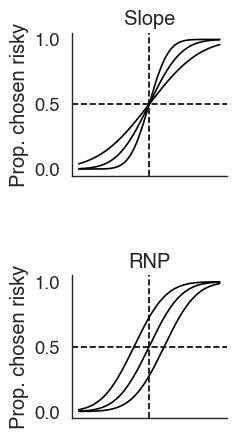

In [7]:
import scipy.stats as ss

sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')

x = np.linspace(-.8, 2, 500)
mu_rn = np.log(1/0.55)
fig, axs = plt.subplots(2,1, figsize=(2,5))

for sd in [.3, .5, .8]:
    d = ss.norm(mu_rn, sd)
    axs[0].plot(x, d.cdf(x), color='k')

for mu in [ mu_rn - 0.3, mu_rn, mu_rn + 0.3]:
    d = ss.norm(mu, .5)
    axs[1].plot(x, d.cdf(x), color='k')

for ax in axs:
    ax.axvline(mu_rn, color='k', linestyle='--')
    ax.axhline(0.5, color='k', linestyle='--')
    ax.set(xticks=[], ylabel='Prop. chosen risky', yticks=[0.0, 0.5, 1.0])

axs[0].set(title='Slope',)
axs[1].set(title='RNP')   
fig.subplots_adjust(hspace = 0.7) # adjust vertical space between axes
#fig.suptitle('prop. chosen risky', y=0.5, x=0,rotation='vertical', va='center')

sns.despine()
#plt.savefig(op.join(plot_folder_path, f'probit-model_illustration_01.pdf'), bbox_inches='tight')


### Posterior distributions of effect sizes | Probit
 model fitted in #-ed lines

In [14]:
import bambi
import arviz as az

n_model = 1
formulae = 'chose_risky ~ x*session*group + (x*session|subject)' 
df['x'] = df['log(risky/safe)']

model = bambi.Model(formulae, link='probit', family='bernoulli', data=df.reset_index())
#traces = model.fit(init='adapt_diag', target_accept=0.9, draws=1000, tune=1000)
#az.to_netcdf(traces, op.join(bids_folder,'derivatives/cogmodels', f'bambi-RNP-fit_trace_model{n_model}.netcdf'))
traces= az.from_netcdf(op.join(bids_folder,'derivatives/cogmodels', f'bambi-RNP-fit_trace_model{n_model}.netcdf'))

from stress_risk.behavior.utils import extract_rnp_precision
intercept, gamma = extract_rnp_precision(traces, model, df, True) # important 
rnp = np.clip(np.exp(intercept/gamma), 0, 1)
rnp['param']= 'rnp'
gamma['param'] = 'gamma'

probit_params = pd.concat([rnp.set_index('param', append=True), gamma.set_index('param', append=True)])
dd = probit_params.xs(2,0,'session') - probit_params.xs(1,0,'session')
dd = dd.stack().stack().rename(mapper={'chose_risky_mean':'y'},axis=1).reset_index('group')
dd['group'] = dd['group'].replace({0: 'control', 1: 'stress'})
dd.set_index('group', append=True, inplace=True)

def get_diffindiff_pval(probit_params, param):
    dd_0= probit_params.xs(param, level='param').xs(0, level='group').xs(1, level='session') - probit_params.xs(param, level='param').xs(0, level='group').xs(2, level='session')
    dd_1= probit_params.xs(param, level='param').xs(1, level='group').xs(1, level='session') - probit_params.xs(param, level='param').xs(1, level='group').xs(2, level='session')
    dd = dd_1 - dd_0
    return np.round(np.mean(dd.stack().stack()>0),3)[0]


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


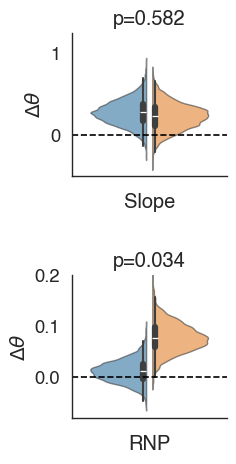

In [60]:
# plot posterior distribution of parameters
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')
params = ['gamma', 'rnp']

fig, axs = plt.subplots(2,1, figsize=(2,5)) #2.5, 1

for ax, param in zip(axs, params):
    sns.violinplot(dd.xs(param,0,'param').reset_index(),y='y', hue='group',split=True,legend=False,gap=.1,alpha=.6, ax=ax) # x='param',
    ax.axhline(0, c='k', ls='--')
    ymin, ymax = ax.get_ylim()
    new_ymax = np.abs(ymin) * 2.5
    pval = get_diffindiff_pval(probit_params, param)
    ax.set(ylim=[ymin, new_ymax], ylabel=None, title=f'p={pval}')
sns.despine()

axs[0].set(ylabel=r'$\Delta\theta$', xlabel='Slope')
axs[1].set(ylabel=r'$\Delta\theta$', xlabel='RNP', yticks=[0,0.1,0.2])   

fig.subplots_adjust(hspace = 0.7) # adjust horizontal space between axes
#plt.savefig(op.join(plot_folder_path, f'probit-model_diffinsessions_violin.pdf'), bbox_inches='tight')


### posterior predictive checks Probit


In [56]:
from stress_risk.behavior.utils import summarize_ppc, plot_prediction, format_bambi_ppc
df['log(risky/safe)'] = df['bin(risky/safe)']

groupby = ['log(risky/safe)', 'session','group']
ppc = format_bambi_ppc(traces, model, df)
ppc = ppc.xs('ll_bernoulli', 0 , 'variable') # instead of 'p', makes the hdi wider
ppc = ppc.reset_index('log(risky/safe)')
ppc['log(risky/safe)'] = ppc.index.get_level_values('bin(risky/safe)')

ppc = ppc.groupby(['subject']+groupby).mean()

ppc_summary = summarize_ppc(ppc, groupby=groupby)
df_summary = df.groupby(groupby)[['chose_risky']].mean()

ppc_summary = ppc_summary.join(df_summary).reset_index()
ppc_summary['prop. chosen risky'] = ppc_summary['chose_risky']
ppc_summary['Predicted acceptance'] = ppc_summary['log(risky/safe)']
ppc_summary['group'] = np.where(ppc_summary['group'] == 0, 'Control', 'Stress') # modify names of group

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_94034/3626401245.py:13: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ppc = ppc.groupby(['subject']+groupby).mean()
/Users/mrenke/git/stress_risk/stress_risk/behavior/utils.py:163: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,


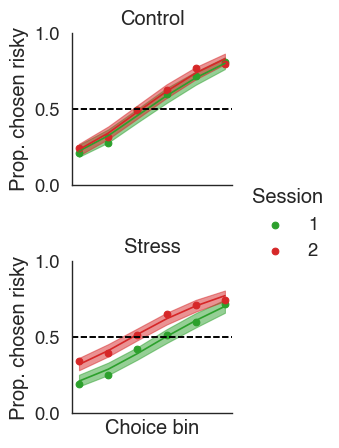

In [58]:
# Plotting
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')
x = 'Predicted acceptance'

#plt.figure(figsize=(5,2)) 
fac = sns.FacetGrid(ppc_summary,
                            hue='session',
                            row='group',
                            palette=sns.color_palette()[2:],
                            height=2.5, # height of each facet in inches --> fits size of figs above
                            aspect=1) # aspect ratio of each facet)

fac.map_dataframe(plot_prediction, x=x) # uses y='p_predicted'
fac.map(plt.scatter, x, 'prop. chosen risky')
fac.map(lambda *args, **kwargs: plt.axhline(.5, c='k', ls='--'))

fac.set_titles('{row_name}')
fac.set(xlabel='Choice bin', ylabel='Prop. chosen risky', xticks=[],yticks=[0.0, 0.5, 1.0]) # for poster
fac.add_legend(title='Session')

fac.fig.subplots_adjust(hspace = 0.5) # adjust horizontal space between axes
fac.fig.set_size_inches(4,5)

#plt.savefig(op.join(plot_folder_path, f'probit-1_ppc.pdf'), bbox_inches='tight')

## PMC model
Perceptual Memory-based Choice model (PMC) 

(former: NLC - noisy logarithmic coding)

### model illustration

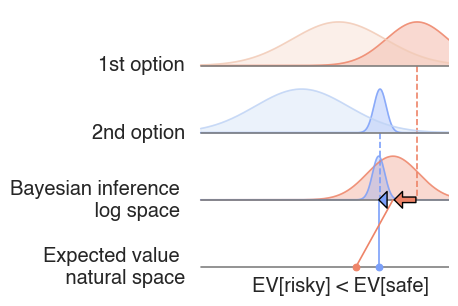

In [3]:
from utils import plot_bayesian_inference, annotat_bayesian_inference
import seaborn as sns 
import matplotlib.pyplot as plt
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')

plt.figure(figsize=(4,3.5))
plot_bayesian_inference(risky_first = True,base = 49)
annotat_bayesian_inference()
#plt.savefig(op.join(plot_folder_path, f'NLC-model_illustration_01.pdf'), bbox_inches='tight')


### Posteriors distributions of effect sizes | PMC

fitted with `behavior/fit_bauerModesl.py 5`
(model-5 specification in `behavior/utils.py`)

In [3]:
import arviz as az
model_label = '5' # model where priors shift together 
idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_label}_trace.netcdf'))

In [5]:
def get_posterior(idata,param,regressor): # adpated version (before was only idata.posterior[param] and 'subject' was and addiotnal index, but that is not what we want here!)
    df = idata.posterior[param+'_mu'].to_dataframe()
    df.index = df.index.set_names(['chain','draw','regressor'])
    df = df.xs(regressor, 0,'regressor')
    df['regressor'] = regressor
    return df


def get_post_diffindiff(idata,param):
    df_control_dif = get_posterior(idata,param,'session')
    df_stress_dif = get_posterior(idata,param,'session') + get_posterior(idata,param,'session:group')
    df_c = pd.concat((df_control_dif, df_stress_dif), axis=0)
    df_c = df_c.set_index('regressor', append=True)
    return df_c

In [6]:
df_prior = get_post_diffindiff(idata,'prior_mu')
df_1e = get_post_diffindiff(idata,'n1_evidence_sd')
df_2e = get_post_diffindiff(idata,'n2_evidence_sd')

dd = pd.concat([df_prior,df_1e,df_2e], axis=1)
dd = dd.stack().to_frame('value')
dd.index = dd.index.set_names(['chain','draw','regressor','param'])
dd.index = dd.index.set_levels(['Control', 'Stress'], level='regressor')

df_prior = get_posterior(idata,'prior_mu','session:group').drop('regressor', axis=1)
df_1e = get_posterior(idata,'n1_evidence_sd','session:group').drop('regressor', axis=1)
df_2e = get_posterior(idata,'n2_evidence_sd','session:group').drop('regressor', axis=1)

dd_difdif = pd.concat([df_prior, df_1e,df_2e], axis=1)

Prior mu: p=0.00225, mean=0.5074289275644218, 95%CI=[0.17777659 0.85194047]
Evidence sd 1st: p=0.2585, mean=0.07367542243979591, 95%CI=[-0.15707291  0.2991171 ]
Evidence sd 2nd: p=0.59625, mean=-0.02630481290557353, 95%CI=[-0.24760736  0.19702976]


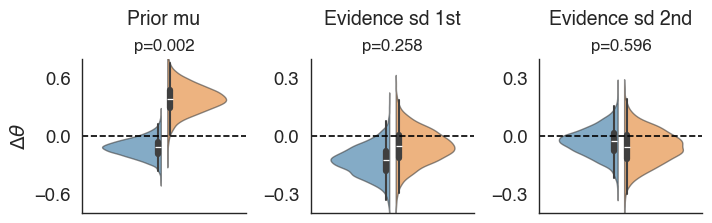

In [7]:
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.5, palette='tab10')

params = dd.index.get_level_values('param').unique()
col_names = ['Prior mu','Evidence sd 1st','Evidence sd 2nd']
y_range_scaler = 0.95
fig, axs = plt.subplots(1,len(params), figsize=(8,2)) #2.5, 1

for ax, param,col_name in zip(axs, params,col_names):
    sns.violinplot(dd.xs(param,0,'param').reset_index(),y='value', hue='regressor',split=True,legend=False,gap=.1,alpha=.6, ax=ax) # x='param',
    p_val = np.round(np.mean(dd_difdif[param]<0),3)
    ax.axhline(0, c='k', ls='--')
    ymin, ymax = ax.get_ylim()
    ax.set(ylim=[-.4,.4], ylabel=None,xlabel=None, yticks=[-.3,0,.3]) #[-ymax*y_range_scaler, ymax*y_range_scaler]
    #ax.set_title(f'p = {p_val}', fontsize=12)

    ax.set_title(f'p={p_val}', fontsize=12)
    ax.annotate(f'{col_name}', xy=(0.5, 1), xytext=(0, 25), 
             xycoords='axes fraction', textcoords='offset points',
             size=14, ha='center', va='baseline',fontweight='bold')
    print(f'{col_name}: p={np.mean(dd_difdif[param]<0)}, mean={np.mean(dd_difdif[param])}, 95%CI={np.percentile(dd_difdif[param], [2.5, 97.5])}')

sns.despine()
axs[0].set(ylabel=r'$\Delta\theta$',ylim=[-.8,.8],yticks=[-.6,0,.6] )
fig.subplots_adjust(wspace = 0.4) # adjust horizontal space between axes
#plt.savefig(op.join(plot_folder_path, f'NLC-{model_label}-post_stres-control_violin.pdf'), bbox_inches='tight')

In [13]:
## posterior predictive check
from stress_risk.behavior.utils import build_model,format_bambi_ppc #, plot_ppc
import arviz as az

model_label = '5'
model = build_model(model_label, df)
model.build_estimation_model()

traces= az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_label}_trace.netcdf'))


/Users/mrenke/mambaforge/envs/pymc_env/lib/python3.12/site-packages/pymc/data.py:423: FutureWarning: Data is now always mutable. Specifying the `mutable` kwarg will raise an error in a future release
  warnings.warn(


In [ ]:
from stress_risk.behavior.utils import plot_ppc

ppc = model.ppc(idata=traces.sel(draw=slice(None, None, 10)), paradigm=df)
# works with behav_fit environment | sometimes not VS notebook but then in the terminal () - tried many things...

/Users/mrenke/git/stress_risk/stress_risk/behavior/utils.py:221: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ppc = ppc.groupby(['subject']+groupby).mean()
/Users/mrenke/git/stress_risk/stress_risk/behavior/utils.py:163: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,


[Text(0.5, 1.0, '')]

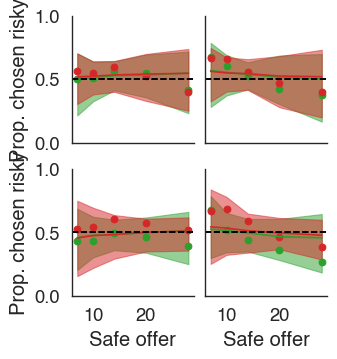

In [5]:

ppc.loc[ppc.index.get_level_values('risky_first')] = 1 - ppc.loc[ppc.index.get_level_values('risky_first')]

fac = plot_ppc(df, ppc, level='group', plot_type=6, var_name='ll_bernoulli', col_wrap=5)

fac.fig.set_size_inches(3.5,3.5)
for legend in fac.fig.legends:
    legend.remove()

fac.axes[0,0].set(ylabel='Prop. chosen risky', yticks=[0,0.5,1],title='')
fac.axes[1,0].set(ylabel='Prop. chosen risky', yticks=[0,0.5,1],title='')
fac.axes[0,1].set(title='')
fac.axes[1,1].set(title='')
#fac.fig.subplots_adjust(hspace = 0.5) # adjust horizontal space between axes
#plt.savefig(op.join(plot_folder_path, f'NLC-ppc_.pdf'), bbox_inches='tight')



## Neural Analysis
first 3 scripts in `/stress_risk/fmri_analysis` 
1. glm: `/glm/fit_glm_denoise.py`
2. encoding: `/encoding_model/fit_model_cv.py`
3. decoding across & within sessions: `encoding_model/decode_select_voxels_cv.py`(within sessions), `encoding_model/decode_svoxels.py`(across session) 

4. derive neural shift und neural uncertainty from decoding:
*  within_ses_decodedE.csv  & within-ses-decod_r-sds.csv -->  `/stress_risk/analyse_results/decode_ana_01.ipynb` 
*  across_ses_decodedE.csv -->  `/stress_risk/analyse_results/decode_ses1-en_ses2-de_ana.ipynb` 

### shift neural coding 


In [7]:
# E_diff
Es_within = pd.read_csv(op.join(bids_folder, 'interim_sum_data', 'within_ses_decodedE.csv'))
Es_across = pd.read_csv(op.join(bids_folder, 'interim_sum_data','across_ses_decodedE.csv'))

Es_within = Es_within.set_index(['subject', 'trial_nr', 'session']).rename(mapper={'E':'E_w', 'sd':'sd_w'}, axis=1).xs(2,0,'session')
Es_across = Es_across.set_index(['subject', 'trial_nr']).rename(mapper={'E':'E_a', 'sd':'sd_a'}, axis=1)

from stress_risk.utils.data import add_cond2df
Es = Es_within.join(Es_across).set_index('risky_first', append=True)
Es = add_cond2df(Es)
Es['E_dif'] = Es['E_a'] - Es['E_w']

  Source  ddof1  ddof2         F     p-unc       np2
0  group      1     47  10.71497  0.001997  0.185653
               T        dof alternative     p-val           CI95%   cohen-d  \
T-test -3.257595  43.754409   two-sided  0.002175  [-0.21, -0.05]  0.935444   

          BF10     power  
T-test  16.965  0.893586  


49

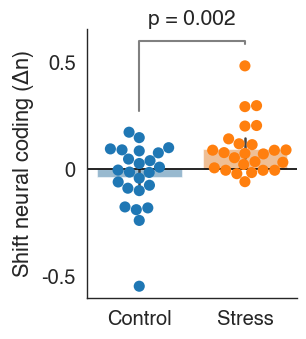

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [8]:
import pingouin
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.636, palette='tab10') # 1.636 = 1.5 * 14.4/13.2 (13.2 = font sizes in affinity designer with font scale 1.5)

temp = Es.groupby(['subject']).mean()
temp['group_name'] = np.where(temp['group'] == 0, 'Control', 'Stress')

plt.figure(figsize=(2.7,3.5)) 
ax = sns.barplot(data=temp.reset_index(), x ='group_name', hue='group_name',y='E_dif', alpha=0.5)
sns.swarmplot(data=temp.reset_index(), x='group_name', hue='group_name', y='E_dif', size=8)

an = pingouin.anova(data=temp.reset_index(), dv='E_dif', between='group')
p_val = np.round(an['p-unc'][0],3)

ax.set(xlabel=None, ylabel = r'Shift neural coding ($\Delta$n)') #title=f'p = {p_val}'
ax.text(0.5, 1, f'p = {p_val}', transform=ax.transAxes, ha='center', va='bottom',fontsize=15)

y_max_control= temp[temp['group_name'] == 'Control']['E_dif'].max()
y_max_stress= temp[temp['group_name'] == 'Stress']['E_dif'].max()
plt.plot([0., 0.,1 , 1], [y_max_control + 0.1, 0.6, 0.6, y_max_stress + 0.1], lw=1.5, color='grey')
plt.yticks([0.5, 0, -0.5], ['0.5', '0', '-0.5'])

plt.axhline(0, c='black')
sns.despine()
#plt.savefig(op.join(plot_folder_path, 'shift-neural-coding_swarm-bar-plot_groups.pdf'), bbox_inches='tight')
print(an)
temp.set_index('group_name', append=True,inplace=True)
ttest = pingouin.ttest(temp.xs('Control',0,'group_name')['E_dif'], temp.xs('Stress',0,'group_name')['E_dif']) # doch einen 2sample ttest machen
print(ttest)
len(temp.reset_index()['subject'].unique())

In [ ]:
# outlier removed
max_val = temp['E_dif'].max()
min_val = temp['E_dif'].min()
filtered_temp = temp[(temp['E_dif'] != max_val) & (temp['E_dif'] != min_val)]

#sns.catplot(data=filtered_temp.reset_index(), x='group_name', y='E_dif',  kind='swarm') #kind='bar',,errorbar=get_hdi

sns.barplot(data=filtered_temp.reset_index(), x='group_name',hue='group_name', y='E_dif', alpha=0.5)
sns.swarmplot(data=filtered_temp.reset_index(), x='group_name', hue='group_name',y='E_dif', size=8)

plt.xlabel(None)
plt.ylabel('shift neural coding')
an = pingouin.anova(data=filtered_temp.reset_index(), dv='E_dif', between='group')
p_val = np.round(an['p-unc'][0],3)
plt.title(f'p = {p_val}')
plt.axhline(0, c='black')

## Neural Data: 2. neural uncertainty

In [10]:
df_wdec = pd.read_csv(op.join(bids_folder, 'interim_sum_data','within-ses-decod_r-sds.csv'))
df_wdec = df_wdec.set_index(['group','subject','session'])

dd = df_wdec.xs(1,0,'session') - df_wdec.xs(2,0,'session')
dd.reset_index(inplace=True)
dd['group'] = dd['group'].str.capitalize()
dd.set_index('group', inplace=True)


  Source  ddof1  ddof2         F     p-unc      np2
0  group      1     47  0.873718  0.354706  0.01825
              T        dof alternative    p-val          CI95%   cohen-d  \
T-test -0.93506  46.971353   two-sided  0.35454  [-0.12, 0.05]  0.267121   

         BF10     power  
T-test  0.407  0.150204  


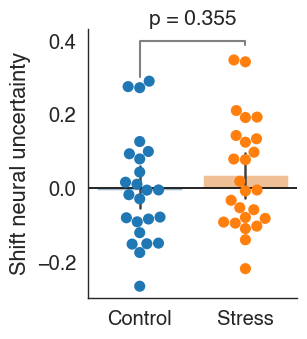

In [11]:
import pingouin
from matplotlib.ticker import FormatStrFormatter
sns.set_theme('paper', 'white', font='helvetica', font_scale=1.636,palette='tab10')
y_var = 'r'

plt.figure(figsize=(2.7,3.5)) 
ax = sns.barplot(data=dd.reset_index(), x='group',hue='group', y=y_var, alpha=0.5)
sns.swarmplot(ax=ax,data=dd.reset_index(), x='group',hue='group', y=y_var,size=8)

an = pingouin.anova(data=dd.reset_index(), dv=y_var, between='group')
p_val = np.round(an['p-unc'][0],3)

ax.set(xlabel=None, ylabel = 'Shift neural uncertainty',title='') # ,title=f'p = {p_val}'; 'n.s.'
ax.text(0.5, 1, f'p = {p_val}', transform=ax.transAxes, ha='center', va='bottom',fontsize=15)

plt.axhline(0, c='black')
sns.despine()

temp = dd.reset_index()
height = 0.5
#ax.text(0.5, 1, 'n.s.', transform=ax.transAxes, ha='center', va='bottom',fontsize=25)

y_max_control= temp[temp['group'] == 'Control'][y_var].max()
y_max_stress= temp[temp['group'] == 'Stress'][y_var].max()
plt.plot([0., 0.,1 , 1], [y_max_control + 0.01, height-0.1, height-0.1, y_max_stress + 0.04], lw=1.5, color='grey')
#plt.yticks([0.5, 0, -0.5], ['0.5', '0', '-0.5'])

#plt.savefig(op.join(plot_folder_path, 'shift_decodability-r_catplot-groups.pdf'), bbox_inches='tight')
print(an)
temp.set_index(['group','subject'], inplace=True)
ttest = pingouin.ttest(temp.xs('Control',0,'group')[y_var], temp.xs('Stress',0,'group')[y_var]) # doch einen 2sample ttest machen
print(ttest)